In [ ]:
# 7.1

import numpy as np
from numpy import linalg as la

M = np.array([1,2,3,0,-4,1,0,3,-1])
mx = M.reshape(3,3)
print(mx)

det = la.det(mx)
print(det)

b = np.array([2,2,-1])
sol = la.solve(mx, b)
print(sol)

trans = mx.T
inv = la.inv(mx)
print(np.allclose(trans, inv))

eig = la.eig(mx)
print(eig[0])

In [ ]:
# 7.3

import numpy as np
from numpy import linalg as la

m = np.array([-0.06698874, -0.87275577, -0.48353891, 0.49272847, -0.45034696, 0.74458463, -0.86760081, -0.1883746, 0.46019978])
mx = m.reshape(3, 3)
print(mx)

trans = mx.T
inv = la.inv(mx)
print(np.allclose(trans, inv))
print(np.isclose(1, la.det(mx)))
eig = la.eig(mx)
eigv = eig[0]
print(eigv)
print(np.isclose(eigv,1))
    
v1 =([np.cos(np.radians(27.4))*np.cos(np.radians(192.25)), np.cos(np.radians(27.4))*np.sin(np.radians(192.25)),np.sin(np.radians(27.4))])
print(v1)
v = [-0.86760081, -0.1883746, 0.46019978]
print(np.isclose(v1, v))
print(la.norm(v))

vr = mx@v
print(vr)
v2 = [0,0,1]
print(np.isclose(vr, v2))

In [ ]:
# 7.5
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

one = np.ones(10)
print(one)
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
x2= x**2
x3 = x**3
x4 = x**4
x5 = x**5
x6 = x**6
x7 = x**7
x8 = x**8
x9 = x**9

A = ([one, x, x2, x3, x4, x5, x6, x7, x8, x9])
Ah = np.vstack(A)
Av = Ah.T
a = np.linalg.solve(Av, y)
print(a)
x2 = np.linspace(1.2, 9.9, 1000)
def polynomial(x, c):
    p=0
    for i, b in enumerate(c):
        p = p + b*x**i 
    return p
p = polynomial(x2, a)
plt.plot(x2, p)
plt.scatter(x, y)
plt.show()

In [ ]:
#7.6
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')
newx = np.linspace(x.min(),x.max(),len(x)*100)  # notice outside the original domain
newy = f(newx)
fig, ax= plt.subplots()
ax.plot(newx, newy)
ax.scatter(x, y)



There are less oscilattions and it varies less strongly between the original points, implying that it is likely more accurate.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip

class interpolate:
    
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def linear(self):
        x = self.x
        y = self.y
        f = ip.interp1d(x, y, 'linear') 
        return f

    def polynomial(self):
        x = self.x
        y = self.y
        coeffs = np.polyfit(x, y, deg = len(x)-1)
        f = np.poly1d(coeffs)
        return f
    
    def spline(self):
        f = ip.interp1d(self.x, self.y, 'cubic')
        return f
    
    def interp(self, X, kind):
        kind = kind
        X = X
        f = ''
        if X > min(self.x) and X < max(self.x):
            if kind == 'linear':
                f = self.linear()
            elif kind == 'polynomial':
                f = self.polynomial()
            elif kind == 'spline':
                f = self.spline()
            return f(X)
        else:
            return "error: please enter a value within the range of x"
        
        
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

i = interpolate(x, y)
X = float(input('Enter an x for which you want to interpolate a y value: '))
liny = i.interp(X, 'linear')
print(f'Linear interpolation: y = {liny}')
poly = i.interp(X, 'polynomial')
print(f'Polynomial interpolation: y = {poly}')
spliney = i.interp(X, 'spline')
print(f'Spline interpolation: y = {spliney}')

In [ ]:
# 7.7
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
x = 0.2
y = 0.7
print(bilinearIP(I, x, y))

/tmp/ipykernel_3019153/139796063.py:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


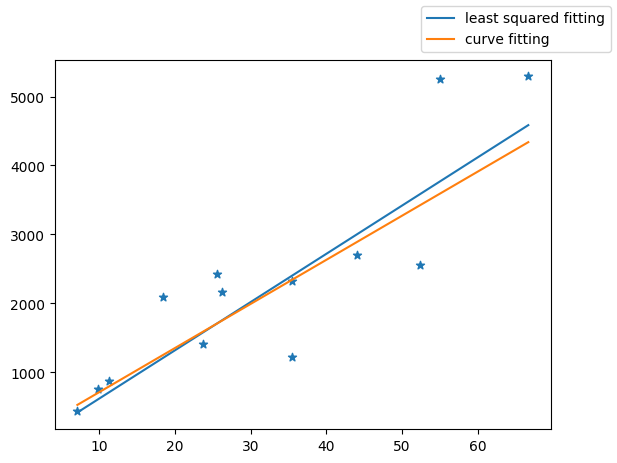

In [53]:
# 7.10
import scipy as sp
import numpy as np
from scipy.optimize import leastsq,curve_fit 
import matplotlib.pyplot as plt

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110]

d = np.array(data[0::4])
v = np.array(data[1::4])
dd = np.array(data[2::4])
dv = np.array(data[3::4])

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + int(beta1)*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = (0, 70.0)          # Initial estimates for beta0 and beta1
data = (d, v, dv)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1)
(betalsq, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results


def model2(x, beta0, beta1):
    return beta0 + beta1*x

# Do the fitting
betacurve, pcov = curve_fit(model2, d, v, sigma = dv)

# Calculate end points for the best straight line
D = np.array([min(d), max(d)])
V = model2(D, beta_start[0], beta_start[1])

fig, ax = plt.subplots()
ax.scatter(d,v, marker= '*')

xmin = d.min(); xmax = d.max()
ymin = model(betalsq,xmin); ymax = model(betalsq,xmax)
ax.plot([xmin, xmax], [ymin, ymax], label = 'least squared fitting')
ymin = model(betacurve, xmin); ymax = model(betacurve,xmax)
ax.plot([xmin, xmax], [ymin, ymax],label = 'curve fitting')
fig.show()
fig.legend()